#Ultralytics YOLO26

Ultralytics YOLO26 is the latest evolution in the YOLO series of real-time object detectors, engineered from the ground up for edge and low-power devices. It introduces a streamlined design that removes unnecessary complexity while integrating targeted innovations to deliver faster, lighter, and more accessible deployment.



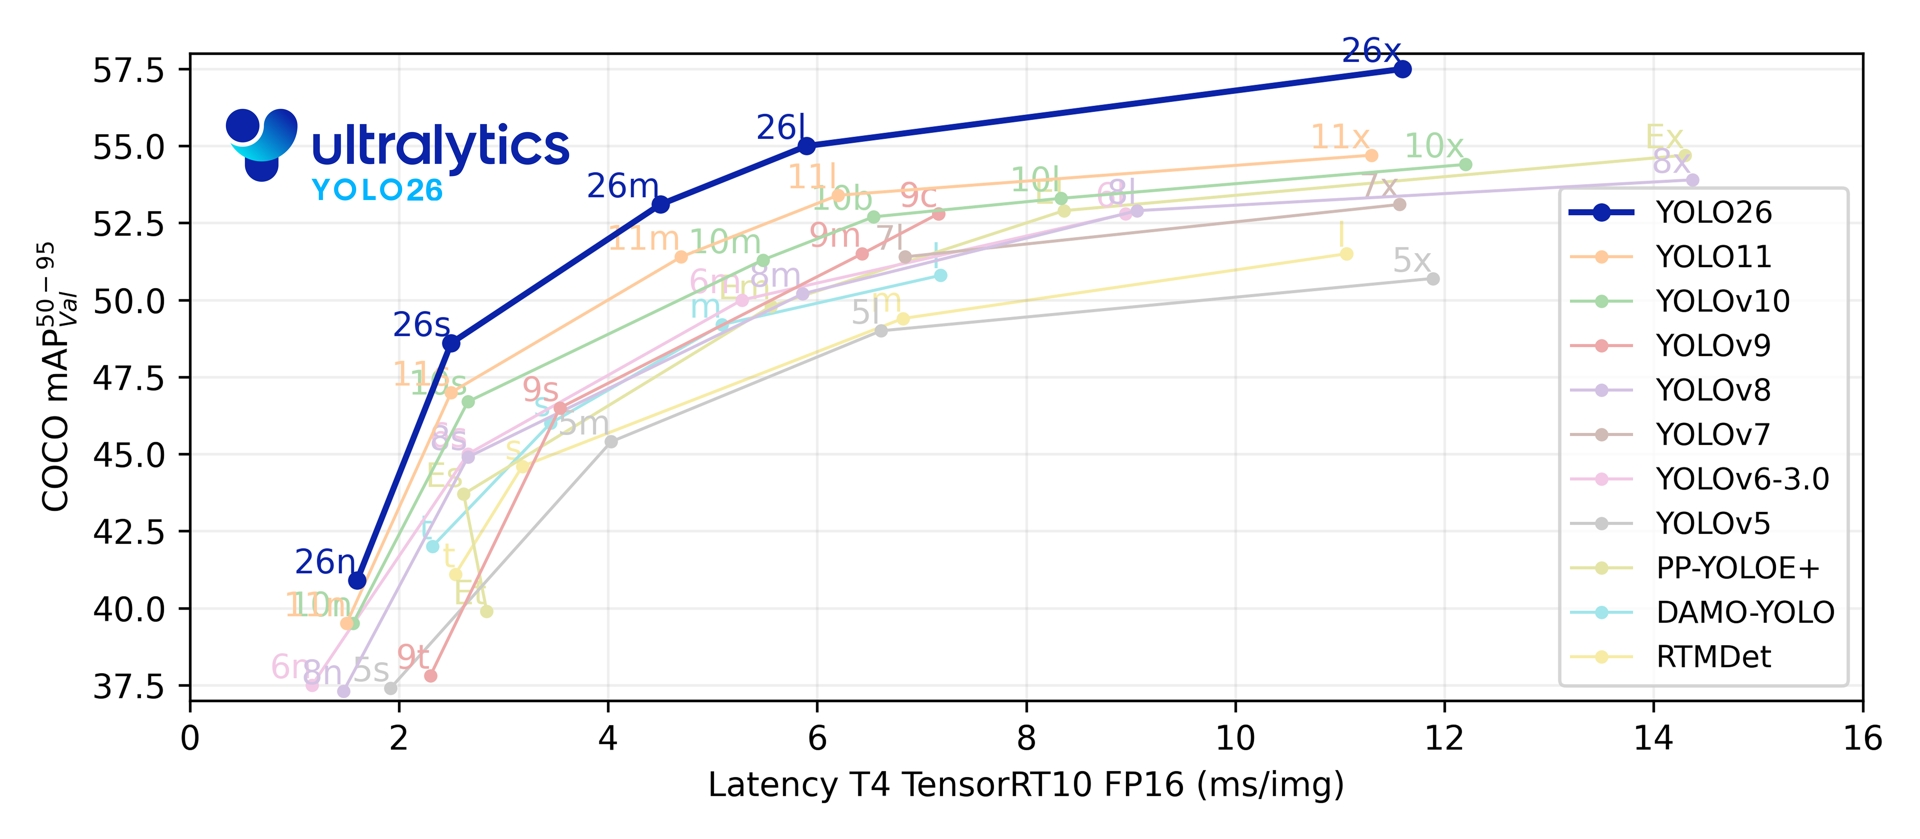

**Step 01: Install All the Required Packages**

In [ ]:
! pip install ultralytics

In [ ]:
import ultralytics
ultralytics.checks()

**Step 02: Import All the Required Libraries**

In [ ]:
from ultralytics import YOLO
from IPython.display import Image

**Step 03: Download Sample Image and Videos**

In [ ]:
! gdown "https://drive.google.com/uc?id=1Xa1EJO_Uwv-qr0i72VK2TaQALz7X0EP1&confirm=t"

In [ ]:
! gdown "https://drive.google.com/uc?id=1l65gM2eQMhutLP9jpySZfaQIAB_OqO2j&confirm=t"

**Step 04: Object Detection on Images & Videos**

**For Images**

In [ ]:
! yolo task=detect mode=predict model=yolo26n.pt source='https://ultralytics.com/images/bus.jpg'

In [ ]:
Image("/content/runs/detect/predict/bus.jpg", width=600)

In [ ]:
! yolo task=detect mode=predict model=yolo26n.pt source='/content/image.jpg'

In [ ]:
Image("/content/runs/detect/predict2/image.jpg", width=600)

**For Videos**

In [ ]:
! yolo task=detect mode=predict model=yolo26n.pt source='/content/video.mp4'

**Display the Output Video**

In [ ]:
! rm /content/result_compressed.mp4

In [ ]:
from IPython.display import HTML
from base64 import b64encode
import os

# Input video path
save_path = '/content/runs/detect/predict3/video.avi'

# Compressed video path
compressed_path = "/content/result_compressed.mp4"

os.system(f"ffmpeg -i {save_path} -vcodec libx264 {compressed_path}")

# Show video
mp4 = open(compressed_path,'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=400 controls>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)

**Step 05: Instance Segmentation on Images & Videos**

**For Images**

In [ ]:
! which yolo

In [ ]:
! yolo task=segment mode=predict model=yolo26n-seg.pt source='https://ultralytics.com/images/bus.jpg'

In [ ]:
Image("/content/runs/segment/predict/bus.jpg", width=600)

In [ ]:
! yolo task=segment mode=predict model=yolo26n-seg.pt source='/content/image.jpg'

In [ ]:
Image("/content/runs/segment/predict2/image.jpg", width=600)

**For Video**

In [ ]:
! yolo task=segment mode=predict model=yolo26n-seg.pt source='video.mp4'

**Display the Output Video**

In [ ]:
! rm /content/result_compressed.mp4

In [ ]:
from IPython.display import HTML
from base64 import b64encode
import os

# Input video path
save_path = '/content/runs/segment/predict3/video.avi'

# Compressed video path
compressed_path = "/content/result_compressed.mp4"

os.system(f"ffmpeg -i {save_path} -vcodec libx264 {compressed_path}")

# Show video
mp4 = open(compressed_path,'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=400 controls>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)

**Step 06: Pose Estimation on Images & Videos**

**For Image**

In [ ]:
! yolo task=pose mode=predict model=yolo26n-pose.pt source='/content/image.jpg'

In [ ]:
Image("/content/runs/pose/predict/image.jpg", width=600)

**For Video**

In [ ]:
! yolo task=pose mode=predict model=yolo26n-pose.pt source='/content/video.mp4'

**Display the Output Video**

In [ ]:
! rm /content/result_compressed.mp4

In [ ]:
from IPython.display import HTML
from base64 import b64encode
import os

# Input video path
save_path = '/content/runs/pose/predict2/video.avi'

# Compressed video path
compressed_path = "/content/result_compressed.mp4"

os.system(f"ffmpeg -i {save_path} -vcodec libx264 {compressed_path}")

# Show video
mp4 = open(compressed_path,'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=400 controls>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)

**Step 07: Image Classification**

In [ ]:
! gdown "https://drive.google.com/uc?id=14jWTZqZoDkjR-VZE7liDoeuvnYGRstzj&confirm=t"

In [ ]:
! yolo task=classify mode=predict model=yolo26x-cls.pt source='/content/carImage.png'

In [ ]:
Image("/content/runs/classify/predict/carImage.jpg")

**Step 08: Oriented Bounding Boxes Object Detection**

Oriented object detection goes a step further than standard object detection by introducing an extra angle to locate objects more accurately in an image.



In [ ]:
! yolo task=obb mode=predict model=yolo26n-obb.pt source='https://ultralytics.com/images/boats.jpg'

In [ ]:
Image("/content/runs/obb/predict/boats.jpg", width=600)

## Step 09: YOLOE-26: Open-Vocabulary Instance Segmentation


**Text Prompt**

In [ ]:
from ultralytics import YOLO

# Initialize model
model = YOLO("yoloe-26l-seg.pt")  # or select yoloe-26s/m-seg.pt for different sizes

# Set text prompt to detect person and bus. You only need to do this once after you load the model.
names = ["person", "bus"]
names = ["bicycle", "helmet", "traffic lights"] # plural ?
model.set_classes(names, model.get_text_pe(names))

# Run detection on the given image
results = model.predict("/content/image.jpg")

# Show results
results[0].show()

**Visual Prompt**

In [ ]:
import numpy as np

from ultralytics import YOLO
from ultralytics.models.yolo.yoloe import YOLOEVPSegPredictor

# Initialize model
model = YOLO("yoloe-26l-seg.pt")

# Define visual prompts using bounding boxes and their corresponding class IDs.
# Each box highlights an example of the object you want the model to detect.
visual_prompts = dict(
    bboxes=np.array(
        [
            [221.52, 405.8, 344.98, 857.54],  # Box enclosing person
            [120, 425, 160, 445],             # Box enclosing sunglasses
        ],
    ),
    cls=np.array(
        [
            0,  # ID to be assigned for person
            1,  # ID to be assigned for glasses
        ]
    ),
)

# Run inference on an image, using the provided visual prompts as guidance
results = model.predict(
    "https://ultralytics.com/images/bus.jpg",
    visual_prompts=visual_prompts,
    predictor=YOLOEVPSegPredictor,
)

# Show results
results[0].show()

**Prompt free**

In [ ]:
from ultralytics import YOLO

# Initialize model
model = YOLO("yoloe-26l-seg-pf.pt")

# Run prediction. No prompts required.
results = model.predict("/content/image.jpg")

# Show results
results[0].show()